In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/q1_heart_disease.csv')

# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# First 5 rows
print("\nFirst 5 rows:")
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 1: Data Loading and Inspection

The dataset contains 800 patient records with 12 features. The target variable is `heart_disease` (1 = disease present, 0 = absent).

- `chest_pain_type`, `resting_ecg`, and `st_slope` are categorical (object type) and will need encoding.
- `resting_bp` has 24 missing values and `cholesterol` has 32 missing values — these will be handled in preprocessing using median imputation.
- No missing values in the target column `heart_disease`.

/var/folders/35/rzrn5spj4jsg6m0xp7tpk4yr0000gn/T/ipykernel_7668/1902107663.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_disease', data=df, palette='Set2')


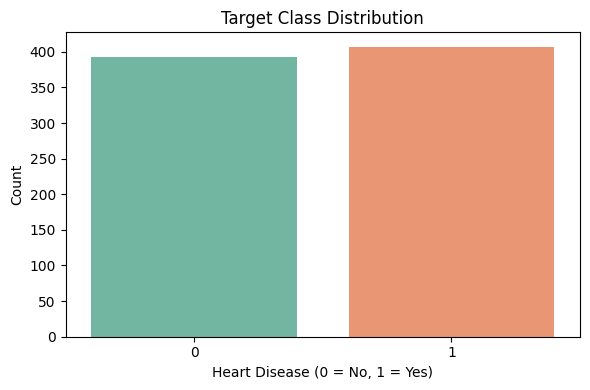

In [23]:
# Task 2: Exploratory Data Analysis

# Plot 1: Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease', data=df, palette='Set2')
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Plot 1: Target Class Distribution

The dataset is nearly balanced with approximately 390 patients without heart disease (0) and 410 with heart disease (1). This near-equal distribution is ideal for classification — it means our models will not be biased towards predicting one class over the other, and accuracy remains a meaningful metric alongside precision and recall.

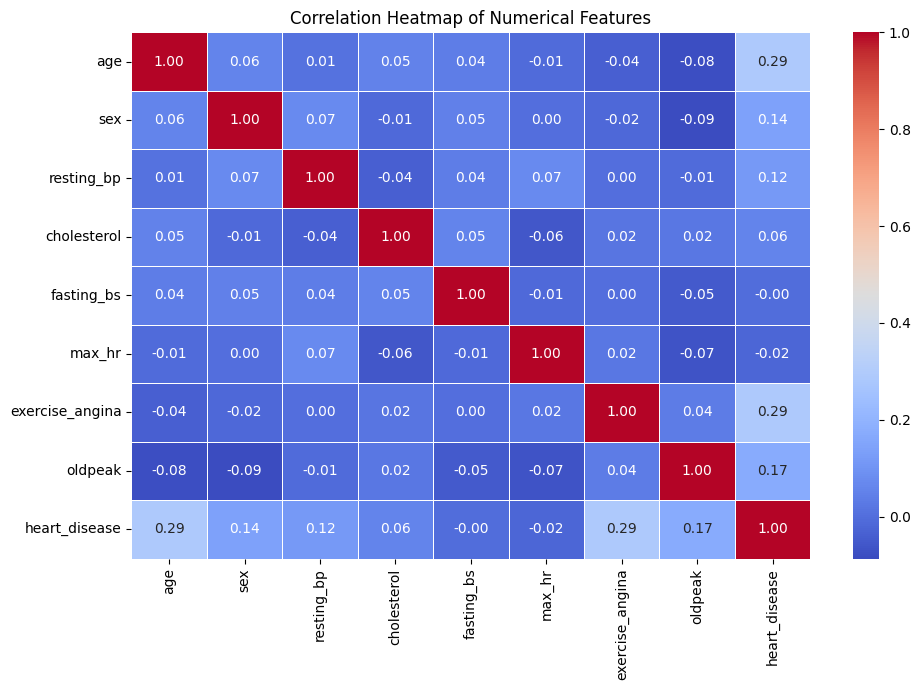

In [24]:
# Plot 2: Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### Plot 2: Correlation Heatmap

The heatmap reveals that most numerical features have low correlation with each other, which is good as it reduces multicollinearity. The strongest correlations with the target `heart_disease` are:
- `age` (0.29) — older patients are more likely to have heart disease
- `exercise_angina` (0.29) — chest pain during exercise is a strong indicator
- `oldpeak` (0.17) — higher ST depression is associated with heart disease
- `sex` (0.14) — gender shows mild correlation with the target

No two features are highly correlated with each other, so we can safely keep all numerical features without dropping any due to multicollinearity.

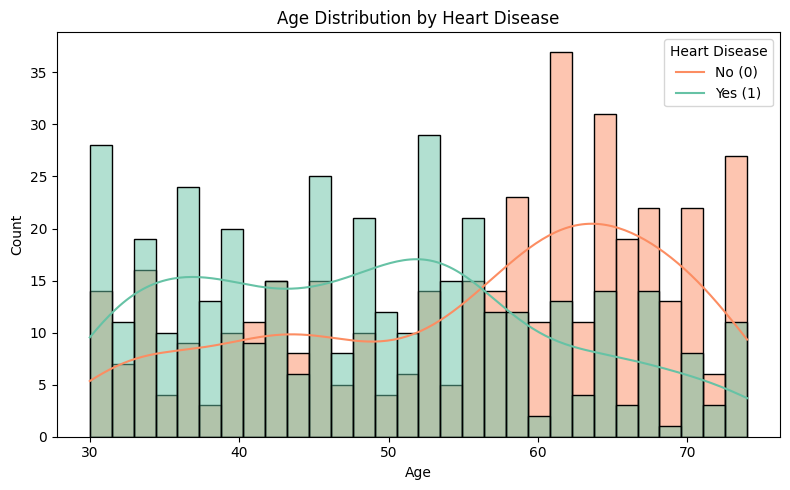

In [25]:
# Plot 3: Age Distribution by Heart Disease
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='heart_disease', bins=30, kde=True, palette='Set2')
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

### Plot 3: Age Distribution by Heart Disease

The histogram shows that younger patients (under 50) are more likely to not have heart disease (green), while older patients (above 55) show a higher prevalence of heart disease (orange). The KDE curves confirm this trend — the heart disease distribution is skewed towards older age groups. This confirms that `age` is an important predictive feature and aligns with the positive correlation (0.29) observed in the heatmap.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Handle missing values with median imputation
df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
df['cholesterol'].fillna(df['cholesterol'].median(), inplace=True)

# Confirm no more missing values
print("Missing values after imputation:")
print(df.isnull().sum())

# Step 2: One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['chest_pain_type', 'resting_ecg', 'st_slope'], drop_first=False)

print("\nShape after encoding:", df_encoded.shape)
print("\nColumns:", df_encoded.columns.tolist())

Missing values after imputation:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

Shape after encoding: (800, 19)

Columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'heart_disease', 'chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


/var/folders/35/rzrn5spj4jsg6m0xp7tpk4yr0000gn/T/ipykernel_7668/285263935.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
/var/folders/35/rzrn5spj4jsg6m0xp7tpk4yr0000gn/T/ipykernel_7668/285263935.py:6: ChainedAssignmentError: A value is being set on a copy of a Data

In [27]:
# Fix: Correct median imputation syntax for newer pandas
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# Confirm no more missing values
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


In [28]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['chest_pain_type', 'resting_ecg', 'st_slope'], drop_first=False)

# Separate features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Scale numerical features
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Target distribution in train:", y_train.value_counts().to_dict())
print("Target distribution in test:", y_test.value_counts().to_dict())

Training set size: (640, 18)
Test set size: (160, 18)
Target distribution in train: {1: 326, 0: 314}
Target distribution in test: {1: 81, 0: 79}


## Task 3: Data Preprocessing

- **Missing values:** `resting_bp` (24 missing) and `cholesterol` (32 missing) were imputed using the median. Median imputation is preferred over mean as it is robust to outliers, which are common in medical data.
- **One-hot encoding:** Applied to `chest_pain_type`, `resting_ecg`, and `st_slope` — expanding the dataset from 12 to 18 features.
- **StandardScaler:** Applied to all numerical features so that no single feature dominates due to scale differences.
- **Train-test split:** 80/20 split with `stratify=y` ensures both sets have proportional class representation (train: 326 vs 314, test: 81 vs 79).

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Train all three models with random_state=42
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("All three models trained successfully!")
print("- Decision Tree")
print("- Random Forest")
print("- Gradient Boosting")

All three models trained successfully!
- Decision Tree
- Random Forest
- Gradient Boosting


In [30]:
from sklearn.metrics import confusion_matrix, classification_report

models = {'Decision Tree': dt, 'Random Forest': rf, 'Gradient Boosting': gb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Decision Tree

Confusion Matrix:
[[56 23]
 [22 59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


Model: Random Forest

Confusion Matrix:
[[60 19]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting

Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77  

## Task 5: Model Evaluation

| Model | Precision | Recall | F1-Score |
|---|---|---|---|
| Decision Tree | 0.72 | 0.72 | 0.72 |
| Random Forest | 0.78 | 0.78 | 0.78 |
| Gradient Boosting | 0.78 | 0.78 | 0.78 |

**Best Model: Random Forest**

Both Random Forest and Gradient Boosting achieve an F1-score of 0.78, outperforming the Decision Tree (0.72). We proceed with Random Forest for hyperparameter tuning as it is faster to train and equally accurate. In medical diagnosis, F1-score is the most important metric as it balances both false positives (unnecessary treatment) and false negatives (missed diagnosis).

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score:", round(grid_search.best_score_, 2))

y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print("Tuned Model Test F1-Score:", round(f1_score(y_test, y_pred_tuned), 2))
print("Baseline RF Test F1-Score: 0.78")

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-Score: 0.83
Tuned Model Test F1-Score: 0.8
Baseline RF Test F1-Score: 0.78


## Task 6: Hyperparameter Tuning

GridSearchCV was used to tune the Random Forest classifier across 12 parameter combinations with 5-fold cross-validation.

**Best Parameters found:**
- `max_depth`: 10
- `min_samples_split`: 5
- `n_estimators`: 200

| Model | Test F1-Score |
|---|---|
| Baseline Random Forest | 0.78 |
| Tuned Random Forest | 0.80 |

Hyperparameter tuning improved the F1-score from 0.78 to 0.80. Limiting `max_depth` to 10 prevents overfitting, while increasing `n_estimators` to 200 adds more trees for better generalisation.